## Contexto
Este estudo tem como objetivo construir um modelo de **regressão logística binária** para prever a probabilidade de inadimplência em solicitações de crédito. Esse tipo de modelo é bastante utilizado no setor financeiro por combinar boa capacidade preditiva com transparência nos resultados, permitindo identificar o impacto de cada variável no risco de crédito.

In [84]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

warnings.filterwarnings('ignore')

In [85]:
credit_card_atributes = pd.read_csv('../data/application_record.csv')
credit_card_status = pd.read_csv('../data/credit_record.csv')


In [86]:
# Verificando dimensões dos DataFrames
print(credit_card_atributes.shape)
print(credit_card_status.shape)

(438557, 18)
(1048575, 3)


In [87]:
# junção do Dataframes
df_credit_card = pd.merge(credit_card_atributes, credit_card_status, on='ID', how='left')

In [88]:
df_credit_card.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0.0,C
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-1.0,C
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-2.0,C
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-3.0,C
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-4.0,C


In [89]:
df_credit_card.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'MONTHS_BALANCE',
       'STATUS'],
      dtype='object')

# Dicionário de dados
| Variável   | Tradução           | Descrição                                |
|------------|--------------------|------------------------------------------|
| ID         | ID DO CLIENTE      | NÚMERO DE IDENTIFICAÇÃO DO CLIENTE       |
| CODE_GENDER| GÊNERO             | GÊNERO DO CLIENTE                        |
| FLAG_OWN_CAR   | TEM UM CARRO  ?         | Y - POSSUI, N - NÃO POSSUI      |
| FLAG_OWN_REALTY  | TEM CASA ?          | Y - POSSUI, N - NÃO POSSUI        |
| CNT_CHILDREN| NÚMERO DE FILHOS          | QTD DE FILHOS                    |
| AMT_INCOME_TOTAL| RENDA ANUAL| RENDA ANUAL EM UNIDADES MONETÁRIAS DO CLIENTE |
| NAME_INCOME_TYPE| CATEGORIA DE RENDA | TIPO DE OCUPAÇÃO           |
| NAME_EDUCATION_TYPE| TIPO DE EDUÇÃO | NÍVEL DE FORMAÇÃO EDUCACIONAL DO CLIENTE           |
| NAME_FAMILY_STATUS | STATUS CIVIL  | STATUS CIVIL DO CLIENTE       |
| NAME_HOUSING_TYPE | TIPO DE MORADIA  | TIPO DE MORADIA DO CLIENTE(APARTAMENTO ALUGADO, CASA, COM OS PAIS)     |
| DAYS_BIRTH | ANIVERSÁRIO | CONTAGEM REGRESSIVA A PARTIR DO DIA ATUAL (0), -1 SIGNIFICA ONTEM     |
| DAYS_EMPLOYED | DIAS EMPREGADO | QUANTIDADE DE DIAS QUE O CLIENTE ESTÁ EMPREGADO SE POSITIVO SIGNIFICA QUE O CLIENTE ESTÁ DESEMPREGADA |
| FLAG_MOBIL | TELEFONE CELULAR | POSSUI TELEFONE CELULAR |
| FLAG_WORK_PHONE | TELEFONE CELULAR CORPORATIVO | POSSUI TELEFONE CELULAR CORPORATIVO |
| FLAG_WORK_PHONE | TELEFONE FIXO | POSSUI TELEFONE FIXO |
| FLAG_EMAIL | E-MAIL| POSSUI UM E-MAIL|
| OCCUPATION_TYPE | PROFISSÃO | PROFISSÃO DO CLIENTE|
| CNT_FAM_MEMBERS| MEMBROS DA FAMÍLIA | QUANTIDADE DE MEMBROS NA FAMÍLIA|
| MONTHS_BALANCE| MES DE REGISTRO | MÊS EM QUE O REGISTRO FOI FEITO 0 MÊS ATUAL -1 UM MÊS ANTES E ETC.|
| STATUS | STATUS DO CRÉDITO | INDICA A SITUAÇÃO DO CLIENTE EM DIAS (0 - 1 A 29, 1 - 30 A 50, 2 - 60 A 89, 3 - 90 A 119, 4 - 120 A 149, 5 - MAIS DE 150 OU DÍVIDA INCOBRÁVEL, C- DIVIDA QUITADA NO MES , X - NENHUM EMPRESTIMO NO MES).|






In [90]:
df_credit_card.shape

(1179815, 20)

In [91]:
df_credit_card.dtypes

ID                       int64
CODE_GENDER             object
FLAG_OWN_CAR            object
FLAG_OWN_REALTY         object
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE        object
NAME_EDUCATION_TYPE     object
NAME_FAMILY_STATUS      object
NAME_HOUSING_TYPE       object
DAYS_BIRTH               int64
DAYS_EMPLOYED            int64
FLAG_MOBIL               int64
FLAG_WORK_PHONE          int64
FLAG_PHONE               int64
FLAG_EMAIL               int64
OCCUPATION_TYPE         object
CNT_FAM_MEMBERS        float64
MONTHS_BALANCE         float64
STATUS                  object
dtype: object

In [92]:
df_credit_card.isnull().sum()/len(df_credit_card)

ID                     0.000000
CODE_GENDER            0.000000
FLAG_OWN_CAR           0.000000
FLAG_OWN_REALTY        0.000000
CNT_CHILDREN           0.000000
AMT_INCOME_TOTAL       0.000000
NAME_INCOME_TYPE       0.000000
NAME_EDUCATION_TYPE    0.000000
NAME_FAMILY_STATUS     0.000000
NAME_HOUSING_TYPE      0.000000
DAYS_BIRTH             0.000000
DAYS_EMPLOYED          0.000000
FLAG_MOBIL             0.000000
FLAG_WORK_PHONE        0.000000
FLAG_PHONE             0.000000
FLAG_EMAIL             0.000000
OCCUPATION_TYPE        0.307614
CNT_FAM_MEMBERS        0.000000
MONTHS_BALANCE         0.340816
STATUS                 0.340816
dtype: float64

In [93]:
# removendo dados nulos da coluana alvo 'STATUS'
df_credit_card = df_credit_card.dropna(subset=['STATUS'])

In [94]:
# Valores nulos após remoção na coluna 'STATUS
df_credit_card.isnull().sum()/len(df_credit_card)

ID                     0.000000
CODE_GENDER            0.000000
FLAG_OWN_CAR           0.000000
FLAG_OWN_REALTY        0.000000
CNT_CHILDREN           0.000000
AMT_INCOME_TOTAL       0.000000
NAME_INCOME_TYPE       0.000000
NAME_EDUCATION_TYPE    0.000000
NAME_FAMILY_STATUS     0.000000
NAME_HOUSING_TYPE      0.000000
DAYS_BIRTH             0.000000
DAYS_EMPLOYED          0.000000
FLAG_MOBIL             0.000000
FLAG_WORK_PHONE        0.000000
FLAG_PHONE             0.000000
FLAG_EMAIL             0.000000
OCCUPATION_TYPE        0.308658
CNT_FAM_MEMBERS        0.000000
MONTHS_BALANCE         0.000000
STATUS                 0.000000
dtype: float64

OCCUPATION - PROFISSSÃO FOI A ÚNICA VARIÁVEL QUE APÓS TRATAMENTO DA COLUNA ALVO STATUS, OS VALORES NULOS DESTA COLUNA SERÃO REFERENCIADOS COMO INDEFINIDO VISTO QUE É UMA COLUNA CATEGÓRICA.

In [95]:
df_credit_card['OCCUPATION_TYPE'].unique()

array([nan, 'Security staff', 'Sales staff', 'Accountants', 'Laborers',
       'Managers', 'Drivers', 'Core staff', 'High skill tech staff',
       'Cleaning staff', 'Private service staff', 'Cooking staff',
       'Low-skill Laborers', 'Medicine staff', 'Secretaries',
       'Waiters/barmen staff', 'HR staff', 'Realty agents', 'IT staff'],
      dtype=object)

In [96]:
df_credit_card['OCCUPATION_TYPE'].fillna('UNDEFINED', inplace=True)

In [97]:
# Tamanho final do Dataframe
df_credit_card.shape

(777715, 20)

<Figure size 800x600 with 0 Axes>

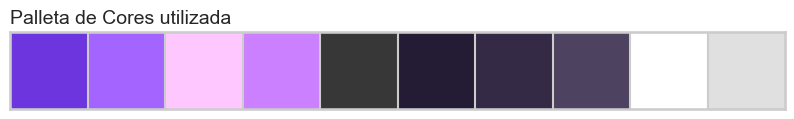

In [99]:
paleta_cores = ['#6c35de','#a364ff','#ffc7ff','#cb80ff', '#373737', '#241b35', '#342a45','#4d425f', '#ffffff', '#e0e0e0']
plt.figure(figsize=(8,6))
sns.palplot(paleta_cores)

plt.title('Palleta de Cores utilizada', loc='left', fontsize=14)
plt.show()

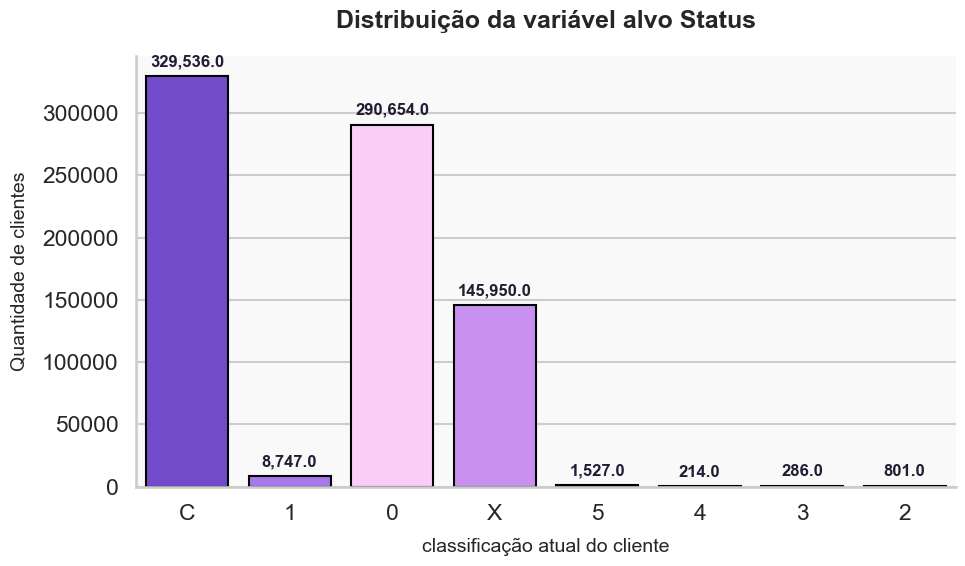

In [126]:
plt.figure(figsize=(10,6))

sns.set_style('whitegrid')
sns.set_context('talk')

ax = sns.countplot(x='STATUS', data=df_credit_card, palette=paleta_cores, edgecolor='black')
plt.title('Distribuição da variável alvo Status', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('classificação atual do cliente', fontsize=14, labelpad=10)
plt.ylabel('Quantidade de clientes', fontsize=14, labelpad=10)

# adicionando os valores acima das barras
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:,}',
                (p.get_x() + p.get_width() / 2, height),
                ha='center',
                va='bottom',
                fontsize=12, fontweight='bold',
                color='#241b35', xytext=(0,5), textcoords='offset points')
    
ax.set_facecolor('#f9f9f9')
plt.gca().spines['top'].set_visible(False)  
plt.gca().spines['right'].set_visible(False)


plt.tight_layout()
plt.show()


Com a visulização acima nota-se maior presença de clientes nas categorias C = divida quitada no mês, 0 = 1 a 29 dias de atraso, X = Nenhum empréstimo no mês, sendo a categora C a mais frequente para os perfis de clientes.

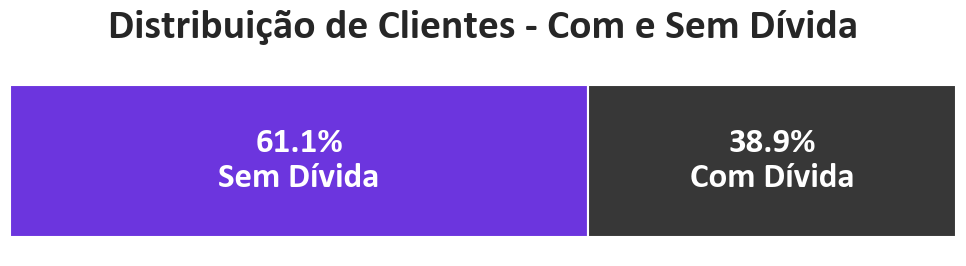

In [177]:
plt.rcParams['font.family'] = 'DejaVu Sans'
df_credit_card['DIVIDA'] = df_credit_card['STATUS'].apply(lambda x: 'SEM DIVIDA' if x in ['C', 'X'] else 'COM DIVIDA')  # Coluna que classifica dívida

percentuais = df_credit_card['DIVIDA'].value_counts(normalize=True)*100
com_divida = percentuais.get('COM DIVIDA', 0)
sem_divida = percentuais.get('SEM DIVIDA', 0)


fig, ax = plt.subplots(figsize=(10, 3))

# Blocos empilhados'#6c35de
ax.barh(0, sem_divida, color='#6c35de')  
ax.barh(0, com_divida, left=sem_divida, color='#373737')  

ax.text(sem_divida/2, 0, f"{sem_divida:.1f}%\nSem Dívida",
        ha='center', va='center', fontsize=25, fontweight='bold', color='white', fontname='Calibri')
ax.text(sem_divida + com_divida/2, 0, f"{com_divida:.1f}%\nCom Dívida",
        ha='center', va='center', fontsize=25, fontweight='bold', color='white', fontname='Calibri')


ax.set_xlim(0, 100)  
ax.set_ylim(-0.5, 0.5)
ax.axis('off')        

plt.title("Distribuição de Clientes - Com e Sem Dívida", 
          fontsize=30, fontweight="bold", pad=20, fontname='Calibri')

plt.tight_layout()
plt.show()